<h1 style="text-align: center;">Project 02: Lexical and Semantic Space Exploration for Embeddings</h1>
<h2>
Name: Ayushman Anupam
</h2>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
pip install googletrans

In [3]:
import os
import re
import psutil
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter, defaultdict
from joblib import Parallel, delayed


from sklearn.metrics.pairwise import cosine_similarity

import nest_asyncio
import asyncio
from googletrans import Translator

current_dir = "/content/drive/Othercomputers/My Laptop/AGDrive/NLP Assignment/Resource"


## Language Used: `Marathi`

## `Task 1: Load and Prepare Co-occurrence Matrix`

### -- displaying the number of cores and total memory --

In [4]:
print(f"Number of CPU cores: {os.cpu_count()}")
print(f"CPU Speed {psutil.cpu_freq().max} GHz")
print(f"Memory: {psutil.virtual_memory().total/2**30} GB")

Number of CPU cores: 2
CPU Speed 0.0 GHz
Memory: 12.671257019042969 GB


### Tokenization of words from corpus and Saving them in directory

In [ ]:
from indicnlp.tokenize.indic_tokenize import trivial_tokenize
marathi_text_path = os.path.join(current_dir, "marathi_sample.txt")
with open(marathi_text_path, "r", encoding="utf-8") as file:
    marathi_text = file.read()

# Marathi (Devanagari only)
tokens = trivial_tokenize(marathi_text)
tokens = [t for t in tokens if re.match(r'^[\u0900-\u097F]+$', t)]

symbols = {
    '==', '|', '.', ',', ':', ';', '!', '?', "''", '``', '` `', '|-', '===',
    "'", 'st', 'nd', 'rd', 'th', "-", "_", "||", '...', '"', 'mm'
}
marathi_tokens = [t for t in tokens if t not in symbols]

output_path = os.path.join(current_dir, "marathi_tokens_sample.txt")
with open(output_path, "w", encoding="utf-8") as file:
    json.dump(marathi_tokens, file, indent=4, ensure_ascii=False)

len(marathi_tokens)
# 7117803


#### Loading Tokens
My system was crashing so I had tokenise and save tokens in my directory.<br>
Then used them in new session

In [5]:
# loading saved tokens
marathi_token_path = os.path.join(current_dir, "marathi_tokens.txt")
with open(marathi_token_path, "r", encoding="utf-8") as file:
     marathi_tokens = json.load(file)
print(len(marathi_tokens))

15462954


In [6]:
# Calculating frequecies
freq_counter = Counter(marathi_tokens)

# vocabulary limit - |V|
vocab_size = 5000
most_common_tokens = freq_counter.most_common(vocab_size)
vocab = {word: idx for idx, (word, _) in enumerate(most_common_tokens)}

print(f"Vocabulary size: {len(vocab)}")

Vocabulary size: 5000


#### Calculating Co-Occurance matrix

In [ ]:
window_size = 2
co_matrix = np.zeros((len(vocab), len(vocab)), dtype=np.int32)

for i, word in enumerate(marathi_tokens):
    if word not in vocab:
        continue
    center_idx = vocab[word]

    # Context window
    start = max(0, i - window_size)
    end = min(len(marathi_tokens), i + window_size + 1)

    for j in range(start, end):
        if i == j:
            continue
        context_word = marathi_tokens[j]
        if context_word in vocab:
            context_idx = vocab[context_word]
            co_matrix[center_idx, context_idx] += 1
# 1m 3ss

### Storing and Saving Co-Occurance matrix

In [7]:
marathi_cooccurrence_path = os.path.join(current_dir, "marathi_cooccurrence_matrix.npy")


# # Save as .npy
# print(f"Saving co-occurrence matrix at {marathi_cooccurrence_path}")
# np.save(marathi_cooccurrence_path, co_matrix)
# print(f"Co-occurrence matrix saved at {marathi_cooccurrence_path}")

# Load back
marathi_cooccurance_matrix = np.load(marathi_cooccurrence_path, allow_pickle=False)
print("Loaded matrix shape:", marathi_cooccurance_matrix.shape)


Loaded matrix shape: (5000, 5000)


### Displaying shape and elements of Co-occurance matrix

In [8]:
print(f"Co-occurrence matrix shape: {marathi_cooccurance_matrix.shape}")
print(marathi_cooccurance_matrix[:3, :12])
print(marathi_cooccurance_matrix[-3:, -12:])

Co-occurrence matrix shape: (5000, 5000)
[[ 4720 11529 12394  5691  1015  2974  4506  3520  1761  4038  3806  5945]
 [11529  2190 10212 13985  6840 40032  7967  7291  2141    58    62  5532]
 [12394 10212  1324  1450  2540  1720  4497   809   831  2069  2539  1501]]
[[  0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  90   0]
 [  0   0   0   0   0   0   0   0   0   0   0 108]]


In [10]:
"""
As we can see last entries of co-occurance matrics are higly sparse
so, 5000 vocabulary size should work
"""

'\nAs we can see last entries of co-occurance matrics are higly sparse\nso, 5000 vocabulary size should work\n'

## `Task 2: Parallelize Correlation Computation`

### Computing Correlation by parallelizing work on all 8 cores in my systems

In [ ]:
def compute_correlation_row(i, full_matrix):
    v_i = full_matrix[i, :]
    v_i_centered = v_i - np.mean(v_i)
    norm_i = np.linalg.norm(v_i_centered)
    result = []
    for j in range(full_matrix.shape[0]):
        v_j = full_matrix[j, :]
        v_j_centered = v_j - np.mean(v_j)
        norm_j = np.linalg.norm(v_j_centered)
        denom = norm_i * norm_j + 1e-8
        numerator = np.dot(v_i_centered, v_j_centered)
        result.append(numerator / denom if denom != 0 else 0.0)
    return np.array(result)


# Computing correlation matrix in parallel
num_cores = os.cpu_count()
correlation_matrix = Parallel(n_jobs=num_cores)(
    delayed(compute_correlation_row)(i, marathi_cooccurance_matrix)
    for i in range(vocab_size)
)
correlation_matrix = np.array(correlation_matrix)

print("Correlation matrix computed")
print("Shape:", correlation_matrix.shape)

# 23m 26.0s

### Saving and Loading Correlation matrix

In [11]:
correlation_matrix_path = os.path.join(current_dir, "marathi_correlation_matrix.npy")

# np.save(correlation_matrix_path, correlation_matrix)
# print(f"Correlation matrix saved at {correlation_matrix_path}")

correlation_matrix = np.load(correlation_matrix_path, mmap_mode='r')
print("Correlation matrix loaded.")
print("Shape:", correlation_matrix.shape)

print(correlation_matrix[:3, :10])

Correlation matrix loaded.
Shape: (5000, 5000)
[[1.         0.25390989 0.31412363 0.18728937 0.32469937 0.26328548
  0.34543065 0.35683165 0.08870486 0.24070512]
 [0.25390989 1.         0.22687508 0.21347425 0.17193954 0.26426019
  0.18072502 0.28754567 0.06774117 0.2854056 ]
 [0.31412363 0.22687508 1.         0.21880875 0.20144269 0.30616156
  0.27581697 0.37105962 0.06855473 0.22043781]]


## `Task 3: Compute Pearson Correlation Matrix`

#### Computing Pearson Correlation matrix

In [ ]:
# function to compute Pearson correlation between two word vectors.
def pearson_corr(a_vec, b_vec):
    a_centered = a_vec - np.mean(a_vec)
    b_centered = b_vec - np.mean(b_vec)

    numerator = np.sum(a_centered * b_centered)
    denominator = np.sqrt(np.sum(a_centered ** 2)) * np.sqrt(np.sum(b_centered ** 2))

    if denominator == 0:
        return 0.0
    return numerator / denominator


# function to compute Pearson correlation matrix for the full co-occurrence matrix.
def compute_pearson_correlation_matrix(co_matrix):
    V = co_matrix.shape[0]
    corr_matrix = np.zeros((V, V), dtype=np.float32)

    # Mean-center and normalize each row
    means = np.mean(co_matrix, axis=1, keepdims=True)
    centered = co_matrix - means
    norms = np.linalg.norm(centered, axis=1, keepdims=True) + 1e-8
    normalized = centered / norms

    for i in range(V):
        for j in range(i, V):
            corr = np.dot(normalized[i], normalized[j])
            corr_matrix[i, j] = corr
            # reflection
            corr_matrix[j, i] = corr

    return corr_matrix

In [ ]:
print("Co-occurrence matrix shape:", marathi_cooccurance_matrix.shape)
pearson_corr_matrix = compute_pearson_correlation_matrix(marathi_cooccurance_matrix)
print("Pearson Correlation matrix shape:", pearson_corr_matrix.shape)
# 1m

Co-occurrence matrix shape: (5000, 5000)
Pearson Correlation matrix shape: (5000, 5000)


#### Saving pearson Matrix for further use

In [12]:
pearson_correlation_matrix_path = os.path.join(current_dir, "marathi_pearson_correlation_matrix.npy")

# np.save(pearson_correlation_matrix_path, pearson_corr_matrix)
# print(f"Correlation matrix saved at {pearson_correlation_matrix_path}")

pearson_correlation_matrix = np.load(pearson_correlation_matrix_path, mmap_mode='r')
print("Correlation matrix loaded.")
print("Shape:", pearson_correlation_matrix.shape)

print(pearson_correlation_matrix[:3, :10])

Correlation matrix loaded.
Shape: (5000, 5000)
[[1.         0.2539099  0.31412363 0.18728937 0.32469937 0.2632855
  0.34543064 0.35683164 0.08870485 0.24070512]
 [0.2539099  1.         0.22687508 0.21347424 0.17193954 0.2642602
  0.18072502 0.28754568 0.06774117 0.2854056 ]
 [0.31412363 0.22687508 1.         0.21880876 0.20144269 0.30616155
  0.27581698 0.37105963 0.06855472 0.22043781]]


### COALS word vector

In [13]:
# Count negative values in the Pearson correlation matrix
num_negative = np.sum(pearson_correlation_matrix < 0)
total_elements = pearson_correlation_matrix.size
percent_negative = (num_negative / total_elements) * 100

print(f"Number of negative values: {num_negative}")
print(f"Total elements: {total_elements}")
print(f"Percentage of negative values: {percent_negative:.2f}%")

Number of negative values: 1607584
Total elements: 25000000
Percentage of negative values: 6.43%


In [14]:
def compute_coals_vectors(corr_matrix):
    # Remove negative entries
    corr_matrix = np.where(corr_matrix < 0, 0, corr_matrix)
    # Normalizing row-wise
    norms = np.linalg.norm(corr_matrix, axis=1, keepdims=True) + 1e-8
    coals_vectors = corr_matrix / norms
    return coals_vectors

# Task 3: COALS word vectors
coals_vectors = compute_coals_vectors(pearson_correlation_matrix)
print("COALS word vectors shape:", coals_vectors.shape)

COALS word vectors shape: (5000, 5000)


In [15]:
# Count negative values in the Pearson correlation matrix
num_negative = np.sum(coals_vectors < 0)
total_elements = coals_vectors.size
percent_negative = (num_negative / total_elements) * 100

print(f"Number of negative values: {num_negative}")
print(f"Total elements: {total_elements}")
print(f"Percentage of negative values: {percent_negative:.2f}%")

Number of negative values: 0
Total elements: 25000000
Percentage of negative values: 0.00%


### `Identifing five (target) common nouns, five verbs and five adjectives from the vocabulary`

In [ ]:
import stanza

# Download Marathi model (run once)
stanza.download('mr')

# Initialize the pipeline
nlp = stanza.Pipeline('mr', processors='tokenize,pos')

# Lists to store results
nouns, verbs, adjectives = [], [], []

for word, freq in most_common_tokens:
    doc = nlp(word)
    for sent in doc.sentences:
        for token in sent.words:
            pos = token.upos             # Universal POS: NOUN, VERB, ADJ, etc.
            if pos == "NOUN" and len(nouns) < 5:
                nouns.append((word, freq))
            elif pos == "VERB" and len(verbs) < 5:
                verbs.append((word, freq))
            elif pos == "ADJ" and len(adjectives) < 5:
                adjectives.append((word, freq))
    # Stop once we have 5 of each
    if len(nouns) == len(verbs) == len(adjectives) == 5:
        break

print("Top 5 nouns:", nouns)
print("Top 5 verbs:", verbs)
print("Top 5 adjectives:", adjectives)

In [16]:
nouns = [('हवामान', 55779), ('संदर्भ', 54469), ('सुविधा', 42173), ('अंतरावर', 38810), ('क्रिकेट', 37834)]
verbs =[('स', 73736), ('केले', 61773), ('असते', 55348), ('तालुक्यातील', 49772), ('केली', 48881)]
adjectives = [('असे', 33222), ('भारतीय', 30116), ('अधिक', 22488), ('येथील', 21486), ('प्रेक्षणीय', 21480)]

# Extract just the words
nouns_words = [w for w, _ in nouns]
verbs_words = [w for w, _ in verbs]
adjectives_words = [w for w, _ in adjectives]
words = nouns_words + verbs_words + adjectives_words

print("Nouns:", nouns_words)
print("Verbs:", verbs_words)
print("Adjectives:", adjectives_words)

Nouns: ['हवामान', 'संदर्भ', 'सुविधा', 'अंतरावर', 'क्रिकेट']
Verbs: ['स', 'केले', 'असते', 'तालुक्यातील', 'केली']
Adjectives: ['असे', 'भारतीय', 'अधिक', 'येथील', 'प्रेक्षणीय']


#### simialrity matrix using COALS vector

In [17]:
# Mapping indices to words
index2word = {idx: word for word, idx in vocab.items()}

# Computing cosine similarity matrix for COALS vectors
cosine_similarity_matrix = cosine_similarity(coals_vectors)
print("Cosine similarity matrix shape:", cosine_similarity_matrix.shape)

# Converting to cosine distance for COALS vectors
cosine_distance_matrix = 1 - cosine_similarity_matrix
print("Cosine distance matrix shape:", cosine_distance_matrix.shape)

Cosine similarity matrix shape: (5000, 5000)
Cosine distance matrix shape: (5000, 5000)


In [18]:
# marathi-english dictionary to convert marathi words into english
marathi_english = {
  "हवामान": "Weather",
  "संदर्भ": "Context",
  "सुविधा": "Facility",
  "अंतरावर": "At a distance",
  "क्रिकेट": "Cricket",
  "थंड": "Cold",
  "हवेली": "Mansion",
  "जवळपासची": "Nearby",
  "जास्त": "More",
  "पुरूष": "Male",
  "असते": "Is",
  "मिरज": "Miraj",
  "फोन": "Phone",
  "मैल": "Mile",
  "महिला": "Women",
  "सामान्यतः": "Generally",
  "दौंड": "Daund",
  "नागरी": "Urban",
  "दवाखाना": "Hospital",
  "झीलंडच्या": "Zealand's",
  "साधारणपणे": "Generally",
  "पंढरपूर": "Pandharpur",
  "सरकारी": "Government",
  "चौरस": "Square",
  "१९": "19",
  "उष्ण": "Hot",
  "वसई": "Vasai",
  "पिण्याचे": "Drinking",
  "प्रति": "Per",
  "ऑस्ट्रेलियन": "Australian",
  "स": "To",
  "केले": "Did/Made",
  "तालुक्यातील": "Of the taluka",
  "केली": "Did/Made (F)",
  "१९३६": "1936",
  "स्वीकारले": "Accepted",
  "तुळजापूर": "Tuljapur",
  "मालमत्ता": "Property",
  "१९१२": "1912",
  "शेवटचे": "Last",
  "नांदगाव": "Nandgaon",
  "भक्ती": "Devotion",
  "१९१८": "1918",
  "बनवले": "Made",
  "फारच": "Very",
  "वाई": "Wai",
  "जाहिरात": "Advertisement",
  "१९४३": "1943",
  "नाते": "Relationship",
  "महाड": "Mahad",
  "किरकोळ": "Retail",
  "१९३२": "1932",
  "ठेवले": "Kept/Put",
  "असून": "Being",
  "बार्शी": "Barshi",
  "कृती": "Action",
  "असे": "Like this",
  "भारतीय": "Indian",
  "अधिक": "More",
  "येथील": "Here",
  "प्रेक्षणीय": "Spectacular",
  "जेथे": "Where",
  "मराठी": "Marathi",
  "ट्रॅक्टर": "Tractor",
  "व": "And",
  "लोकजीवन": "Folklife",
  "कारण": "Because",
  "अमेरिकन": "American",
  "पेक्षा": "Than",
  "जनगणनेनुसार": "According to the census",
  "पावसाळ्यात": "In the rainy season",
  "वाढले": "Increased",
  "प्रख्यात": "Renowned",
  "बँका": "Banks",
  "७८": "78",
  "त्याचप्रमाणे": "Similarly",
  "पुण्यातील": "From Pune",
  "क्रीडांगण": "Playground",
  "६१": "61",
  "वर्षभर": "All year round",
  "सध्या": "Currently",
  "रशियन": "Russian",
  "कूरियर": "Courier",
  "७१": "71",
  "मिलीमीटर": "Millimeter",
  "खेळणारी": "Playing (F)",
  "ज्याला": "Which",
  "स्थळे": "Places",
  "१९७१": "1971",
  "१९८०": "1980",
  "प्रमुख": "Main",
  "लाड": "Favorite",
  "काढली": "Removed/Drawn",
  "राहते": "Lives",
  "बाह्यदुवे": "External links",
  "खेळलेला": "Played (M)",
  "सर्वसाधारण": "General",
  "तालुक्यात": "In the taluka",
  "तिच्या": "Her",
  "किमी": "Km",
  "कमी": "Less",
  "करायचे": "To do",
  "दिसली": "Appeared",
  "१९९१": "1991",
  "स्थान": "Place",
  "सुप्रसिद्ध": "Famous",
  "बुद्रुक": "Budruk",
  "बांधले": "Built",
  "१०": "10",
  "लावली": "Applied/Put",
  "समशीतोष्ण": "Temperate",
  "जामणी": "Jamani",
  "महाराष्ट्रातील": "In Maharashtra",
  "१९४१": "1941",
  "कोरडे": "Dry",
  "खेळणारा": "Playing (M)",
  "१९८९": "1989",
  "ठेवली": "Kept/Put (F)",
  "आकाराचे": "Of shape",
  "मालवण": "Malvan",
  "शहादा": "Shahada",
  "धार": "Edge",
  "जिंतूर": "Jintur",
  "गावातील": "Of the village",
  "महान": "Great"
}

### Cosine Similarity Table using COALS vectors

In [19]:
nest_asyncio.apply()
translator = Translator()

async def translate_to_english(word):
    try:
        result = await asyncio.to_thread(translator.translate, word, src='mr', dest='en')
        english_word = result.text.strip()
        if not english_word or english_word == word:
            english_word = marathi_english.get(word, word)
    except Exception:
        english_word = marathi_english.get(word, word)
    return english_word

# --- Similarity helper function ---
def top_k_similar(target_word, k=5):
    if target_word not in vocab:
        print(f"{target_word} not in vocab! Skipping.")
        return []
    idx = vocab[target_word]
    dist_scores = cosine_distance_matrix[idx].copy()
    dist_scores[idx] = np.inf
    top_indices = dist_scores.argsort()[:k]
    return [(index2word[i], dist_scores[i]) for i in top_indices]

async def create_similarity_table(target_words):
    results = {w: top_k_similar(w) for w in target_words}

    all_words = set(target_words)
    for sims in results.values():
        all_words.update([w for w, _ in sims])

    translations = {}
    for w in all_words:
        translations[w] = await translate_to_english(w)

    table_data = {}
    stored_results = {}

    for word in target_words:
        column = []
        stored_results[word] = []
        for sim_word, dist in results[word]:
            entry = f"{sim_word} ({dist:.4f} - {translations[sim_word]})"
            column.append(entry)
            stored_results[word].append({
                "word": sim_word,
                "distance": float(dist),
                "english": translations[sim_word]
            })
        table_data[f"{word} ({translations[word]})"] = column

    df = pd.DataFrame(table_data)
    return df, stored_results

async def main():
    global corr_similarity_storage
    corr_similarity_storage = {"nouns": {}, "verbs": {}, "adjectives": {}}

    print("Nouns Similarity Table:")
    corr_simi_nouns_table, corr_similarity_storage["nouns"] = await create_similarity_table([w for w, _ in nouns])
    display(corr_simi_nouns_table)

    print("\nVerbs Similarity Table:")
    corr_simi_verbs_table, corr_similarity_storage["verbs"] = await create_similarity_table([w for w, _ in verbs])
    display(corr_simi_verbs_table)

    print("\nAdjectives Similarity Table:")
    corr_simi_adjectives_table, corr_similarity_storage["adjectives"] = await create_similarity_table([w for w, _ in adjectives])
    display(corr_simi_adjectives_table)

    print("All results stored in `corr_similarity_storage`")
await main()


Nouns Similarity Table:


/usr/local/lib/python3.12/dist-packages/nest_asyncio.py:139: RuntimeWarning: coroutine 'Translator.translate' was never awaited
  handle = None


,हवामान (Weather),संदर्भ (Context),सुविधा (Facility),अंतरावर (At a distance),क्रिकेट (Cricket)
0,थंड (0.0517 - Cold),हवेली (0.0510 - Mansion),जवळपासची (0.2689 - Nearby),जास्त (0.0380 - More),पुरूष (0.0394 - Male)
1,असते (0.0748 - Is),मिरज (0.0576 - Miraj),फोन (0.2725 - Phone),मैल (0.0514 - Mile),महिला (0.0457 - Women)
2,सामान्यतः (0.0766 - Generally),दौंड (0.0633 - Daund),नागरी (0.2904 - Urban),दवाखाना (0.0515 - Hospital),झीलंडच्या (0.0545 - Zealand's)
3,साधारणपणे (0.0822 - Generally),पंढरपूर (0.0641 - Pandharpur),सरकारी (0.2913 - Government),चौरस (0.0625 - Square),१९ (0.0572 - 19)
4,उष्ण (0.0827 - Hot),वसई (0.0682 - Vasai),पिण्याचे (0.2934 - Drinking),प्रति (0.0627 - Per),ऑस्ट्रेलियन (0.0576 - Australian)



Verbs Similarity Table:


/usr/local/lib/python3.12/dist-packages/nest_asyncio.py:139: RuntimeWarning: coroutine 'Translator.translate' was never awaited
  handle = None


...


Adjectives Similarity Table:


/usr/local/lib/python3.12/dist-packages/nest_asyncio.py:139: RuntimeWarning: coroutine 'Translator.translate' was never awaited
  handle = None
/usr/lib/python3.12/concurrent/futures/thread.py:95: RuntimeWarning: coroutine 'Translator.translate' was never awaited
  del work_item


,असे (Like this),भारतीय (Indian),अधिक (More),येथील (Here),प्रेक्षणीय (Spectacular)
0,जेथे (0.0063 - Where),मराठी (0.0090 - Marathi),ट्रॅक्टर (0.0696 - Tractor),व (0.1213 - And),लोकजीवन (0.1872 - Folklife)
1,कारण (0.0077 - Because),अमेरिकन (0.0115 - American),पेक्षा (0.0699 - Than),जनगणनेनुसार (0.1241 - According to the census),सुविधा (0.3944 - Facility)
2,वाढले (0.0080 - Increased),प्रख्यात (0.0124 - Renowned),बँका (0.0787 - Banks),७८ (0.1304 - 78),पावसाळ्यात (0.4013 - In the rainy season)
3,त्याचप्रमाणे (0.0081 - Similarly),पुण्यातील (0.0125 - From Pune),क्रीडांगण (0.0854 - Playground),६१ (0.1326 - 61),वर्षभर (0.4426 - All year round)
4,सध्या (0.0082 - Currently),रशियन (0.0130 - Russian),कूरियर (0.0886 - Courier),७१ (0.1334 - 71),मिलीमीटर (0.4460 - Millimeter)


All results stored in `corr_similarity_storage`


/usr/local/lib/python3.12/dist-packages/nest_asyncio.py:139: RuntimeWarning: coroutine 'Translator.translate' was never awaited
  handle = None


## `Task 4: Apply Singular Value Decomposition (SVD)`

In [20]:
# Performing SVD
U, S, VT = np.linalg.svd(pearson_correlation_matrix, full_matrices=False)
# 2m 11s

Minimum embedding dimension to reach 99% variance: 30
Minimum embedding dimension to reach 99.9% variance: 329
Minimum embedding dimension to reach 99.99% variance: 1108


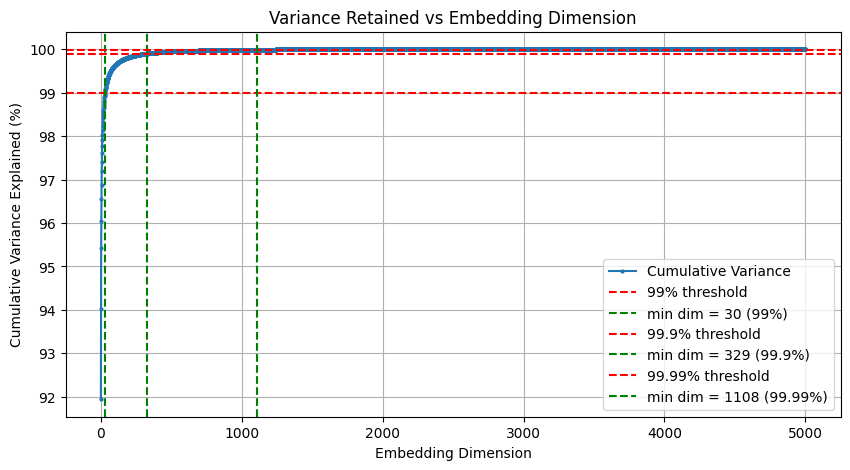

In [21]:
# Computing explained variance through singular values
explained_variance = (S ** 2) / np.sum(S ** 2)
cumulative_variance = np.cumsum(explained_variance) * 100  # percentage

# Thresholds
thresholds = [99, 99.9, 99.99]
min_dims = {}

for th in thresholds:
    min_dim = np.argmax(cumulative_variance >= th) + 1
    min_dims[th] = min_dim
    print(f"Minimum embedding dimension to reach {th}% variance: {min_dim}")

# Plotting cumulative variance and thresholds
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', markersize=2, label="Cumulative Variance")
for th, dim in min_dims.items():
    plt.axhline(y=th, color='r',linestyle="--", label=f"{th}% threshold")
    plt.axvline(x=dim, color='g', linestyle="--", label=f"min dim = {dim} ({th}%)")

plt.xlabel("Embedding Dimension")
plt.ylabel("Cumulative Variance Explained (%)")
plt.title("Variance Retained vs Embedding Dimension")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
"""
from above see that 99.99 % variance is explained by 1108 dimension, which is almost close to all variance.
so we can get dense vectors of dimension 1108 without losing almost any information from data
"""
embedding_dim = 1108
S_diag = np.diag(np.sqrt(S[:embedding_dim]))
pearson_dense_embeddings = np.dot(U[:, :embedding_dim], S_diag)
print("Dense embeddings shape:", pearson_dense_embeddings.shape)

Dense embeddings shape: (5000, 1108)


#### Counting -ve values in dense vectors

In [23]:
# Count negative values in the Pearson correlation matrix
num_negative = np.sum(pearson_dense_embeddings < 0)
total_elements = pearson_dense_embeddings.size
percent_negative = (num_negative / total_elements) * 100

print(f"Number of negative values: {num_negative}")
print(f"Total elements: {total_elements}")
print(f"Percentage of negative values: {percent_negative:.2f}%")

Number of negative values: 2774932
Total elements: 5540000
Percentage of negative values: 50.09%


#### Savind dense embedding and loading it for further use

In [24]:
marathi_dense_vectors_path = os.path.join(current_dir, "marathi_dense_embedding.npy")

# Save as .npy
# print(f"Saving pearson dense vectors at {marathi_dense_vectors_path}")
# np.save(marathi_dense_vectors_path, pearson_dense_embeddings)
# print(f"Co-occurrence matrix saved at {marathi_dense_vectors_path}")

# Load back
pearson_dense_embeddings = np.load(marathi_dense_vectors_path, allow_pickle=False)
print("Loaded matrix shape:", pearson_dense_embeddings.shape)


Loaded matrix shape: (5000, 1108)


#### similarity matrix for dense embedddings

In [25]:
# cosine similarity matrix for pearson dense cosine matric
pearson_dense_cosine_similarity_matrix = cosine_similarity(pearson_dense_embeddings)
print("Cosine similarity of pearson dense embeddings matrix shape:", pearson_dense_cosine_similarity_matrix.shape)

# Converting to cosine distance
pearson_dense_cosine_distance_matrix = 1 - pearson_dense_cosine_similarity_matrix
print("Cosine distance matrix of pearson dense embeddings matrix shape:", pearson_dense_cosine_distance_matrix.shape)

# Mapping indices to words
index2word = {idx: word for word, idx in vocab.items()}

Cosine similarity of pearson dense embeddings matrix shape: (5000, 5000)
Cosine distance matrix of pearson dense embeddings matrix shape: (5000, 5000)


#### Similarity table for Dense embeddings

In [27]:
translator = Translator()
async def translate_to_english(word):
    try:
        result = await asyncio.to_thread(
            translator.translate, word, src="mr", dest="en"
        )
        english_word = result.text.strip()
        if not english_word or english_word == word:
            english_word = marathi_english.get(word, word)
    except Exception:
        english_word = marathi_english.get(word, word)
    return english_word

async def create_dense_similarity_table(target_words, top_k=5):
    results = {}
    all_words_to_translate = set(target_words)

    for word in target_words:
        if word not in vocab:
            print(f"{word} not in vocab! Skipping similar words.")
            results[word] = []
            continue

        idx = vocab[word]
        dist_scores = pearson_dense_cosine_distance_matrix[idx].copy()
        dist_scores[idx] = float("inf")
        top_indices = dist_scores.argsort()[:top_k]
        sims = [(index2word[i], dist_scores[i]) for i in top_indices]
        results[word] = sims
        all_words_to_translate.update([w for w, _ in sims])

    translations = {}
    for w in all_words_to_translate:
        translations[w] = await translate_to_english(w)

    table_data = {}
    stored_results = {}

    for word in target_words:
        column = []
        stored_results[word] = []
        for sim_word, dist in results[word]:
            entry = f"{sim_word} ({dist:.4f} - {translations[sim_word]})"
            column.append(entry)
            stored_results[word].append({
                "word": sim_word,
                "distance": float(dist),
                "english": translations[sim_word]
            })
        table_data[f"{word} ({translations[word]})"] = column

    df = pd.DataFrame(table_data)
    return df, stored_results

async def main_dense():
    global dense_corr_similarity_storage
    dense_corr_similarity_storage = {"nouns": {}, "verbs": {}, "adjectives": {}}

    print("Nouns Dense Distance Table:")
    dense_simi_nouns_table, dense_corr_similarity_storage["nouns"] = await create_dense_similarity_table([w for w, _ in nouns])
    display(dense_simi_nouns_table)

    print("\nVerbs Dense Distance Table:")
    dense_simi_verbs_table, dense_corr_similarity_storage["verbs"] = await create_dense_similarity_table([w for w, _ in verbs])
    display(dense_simi_verbs_table)

    print("\nAdjectives Dense Distance Table:")
    dense_simi_adjectives_table, dense_corr_similarity_storage["adjectives"] = await create_dense_similarity_table([w for w, _ in adjectives])
    display(dense_simi_adjectives_table)

    print("All results stored in `dense_corr_similarity_storage`")
await main_dense()


Nouns Dense Distance Table:


,हवामान (Weather),संदर्भ (Context),सुविधा (Facility),अंतरावर (At a distance),क्रिकेट (Cricket)
0,सर्वसाधारण (0.4063 - General),लाड (0.2734 - Favorite),जवळपासची (0.3882 - Nearby),किमी (0.2068 - Km),महिला (0.3104 - Women)
1,फारच (0.4438 - Very),जामणी (0.2866 - Jamani),नागरी (0.4170 - Urban),क्रीडांगण (0.4322 - Playground),खेळणारा (0.3208 - Playing (M))
2,सामान्यतः (0.4974 - Generally),बाह्यदुवे (0.3717 - External links),प्रेक्षणीय (0.4447 - Spectacular),१० (0.4385 - 10),खेळणारी (0.3266 - Playing (F))
3,कोरडे (0.4981 - Dry),मालवण (0.4115 - Malvan),संदर्भ (0.5282 - Context),पेक्षा (0.4480 - Than),झीलंडच्या (0.3276 - Zealand's)
4,स्थान (0.5024 - Place),शहादा (0.4212 - Shahada),स्थळे (0.6177 - Places),अधिक (0.4541 - More),खेळलेला (0.3452 - Played (M))



Verbs Dense Distance Table:


/usr/local/lib/python3.12/dist-packages/nest_asyncio.py:139: RuntimeWarning: coroutine 'Translator.translate' was never awaited
  handle = None
/usr/lib/python3.12/concurrent/futures/thread.py:95: RuntimeWarning: coroutine 'Translator.translate' was never awaited
  del work_item


,स (To),केले (Did/Made),असते (Is),तालुक्यातील (Of the taluka),केली (Did/Made (F))
0,१९८० (0.2331 - 1980),धार (0.3915 - Edge),उष्ण (0.4085 - Hot),जामणी (0.2268 - Jamani),लावली (0.3674 - Applied/Put)
1,१९७१ (0.2353 - 1971),स्वीकारले (0.4466 - Accepted),फारच (0.4501 - Very),लाड (0.3259 - Favorite),ठेवली (0.4222 - Kept/Put (F))
2,१९८९ (0.2425 - 1989),करायचे (0.4468 - To do),साधारणपणे (0.4876 - Generally),महाराष्ट्रातील (0.3467 - In Maharashtra),तिच्या (0.4414 - Her)
3,१९९१ (0.2455 - 1991),बांधले (0.4721 - Built),कोरडे (0.5010 - Dry),जिंतूर (0.3562 - Jintur),काढली (0.4659 - Removed/Drawn)
4,१९४१ (0.2467 - 1941),ठेवले (0.4799 - Kept/Put),सर्वसाधारण (0.5614 - General),शहादा (0.3575 - Shahada),दिसली (0.4930 - Appeared)



Adjectives Dense Distance Table:


/usr/local/lib/python3.12/dist-packages/nest_asyncio.py:139: RuntimeWarning: coroutine 'Translator.translate' was never awaited
  handle = None
/usr/lib/python3.12/concurrent/futures/thread.py:95: RuntimeWarning: coroutine 'Translator.translate' was never awaited
  del work_item


,असे (Like this),भारतीय (Indian),अधिक (More),येथील (Here),प्रेक्षणीय (Spectacular)
0,ज्याला (0.2553 - Which),अमेरिकन (0.2411 - American),कमी (0.1220 - Less),समशीतोष्ण (0.3231 - Temperate),स्थळे (0.3473 - Places)
1,जेथे (0.2766 - Where),मराठी (0.2468 - Marathi),१० (0.1323 - 10),राहते (0.4693 - Lives),सुविधा (0.4447 - Facility)
2,त्याचप्रमाणे (0.2876 - Similarly),प्रख्यात (0.2592 - Renowned),ट्रॅक्टर (0.3198 - Tractor),सामान्यतः (0.5561 - Generally),लोकजीवन (0.5169 - Folklife)
3,गावातील (0.2909 - Of the village),सुप्रसिद्ध (0.2652 - Famous),पेक्षा (0.3646 - Than),उष्ण (0.5796 - Hot),मिलीमीटर (0.6605 - Millimeter)
4,कारण (0.2945 - Because),महान (0.2953 - Great),बँका (0.3756 - Banks),स्थान (0.5894 - Place),नागरी (0.6875 - Urban)


All results stored in `dense_corr_similarity_storage`


/usr/local/lib/python3.12/dist-packages/nest_asyncio.py:139: RuntimeWarning: coroutine 'Translator.translate' was never awaited
  handle = None


#### overall result - similarity using both methods

In [28]:
def compare_similarity_storages(storage1, storage2):
    overlap_summary = {"nouns": {}, "verbs": {}, "adjectives": {}}

    for pos in ["nouns", "verbs", "adjectives"]:
        for word in storage1[pos]:
            words_dense = {entry["word"] for entry in storage1[pos][word]}
            words_orig = {entry["word"] for entry in storage2[pos].get(word, [])}
            overlap_count = len(words_dense.intersection(words_orig))
            overlap_summary[pos][word] = {
                "dense_topk": words_dense,
                "orig_topk": words_orig,
                "overlap_count": overlap_count
            }

    return overlap_summary

similarity_overlap = compare_similarity_storages(dense_corr_similarity_storage, corr_similarity_storage)
for word, info in list(similarity_overlap["nouns"].items())[:10]:
    print(f"{word}: overlap {info['overlap_count']} / {len(info['dense_topk'])}")
    print(f"  Dense top-k: {info['dense_topk']}")
    print(f"  Original top-k: {info['orig_topk']}\n")


हवामान: overlap 1 / 5
  Dense top-k: {'कोरडे', 'सर्वसाधारण', 'फारच', 'सामान्यतः', 'स्थान'}
  Original top-k: {'असते', 'उष्ण', 'सामान्यतः', 'थंड', 'साधारणपणे'}

संदर्भ: overlap 0 / 5
  Dense top-k: {'जामणी', 'बाह्यदुवे', 'मालवण', 'शहादा', 'लाड'}
  Original top-k: {'हवेली', 'पंढरपूर', 'वसई', 'मिरज', 'दौंड'}

सुविधा: overlap 2 / 5
  Dense top-k: {'स्थळे', 'प्रेक्षणीय', 'जवळपासची', 'संदर्भ', 'नागरी'}
  Original top-k: {'पिण्याचे', 'सरकारी', 'जवळपासची', 'नागरी', 'फोन'}

अंतरावर: overlap 0 / 5
  Dense top-k: {'अधिक', 'किमी', 'क्रीडांगण', 'पेक्षा', '१०'}
  Original top-k: {'दवाखाना', 'प्रति', 'मैल', 'चौरस', 'जास्त'}

क्रिकेट: overlap 2 / 5
  Dense top-k: {'खेळलेला', 'खेळणारा', 'महिला', 'झीलंडच्या', 'खेळणारी'}
  Original top-k: {'ऑस्ट्रेलियन', 'महिला', '१९', 'झीलंडच्या', 'पुरूष'}



## ` Task 5: Analysis and Report`

<div style="border:2px solid #3344ffff; padding:10px; border-radius:8px;">

#### `1. Analyze how retaining negative correlations affected/improved the quality of embeddings`

### **Impact of Retaining Negative Correlations**


1. **Dense embeddings** with negative  correlations entries are showing some **overlapping similar words** that make more semantic sense compared to the original (sparse) embeddings.

   * Example: `सुविधा` → Dense: `नागरी, जवळपासची` vs Original: `नागरी, जवळपासची, पिण्याचे`
Which shows, negative correlations help capture subtle anti-associations in the data, producing more relevant nearest neighbors.

2. **Original COALS embeddings** (without negative correlations) produce **zero negative values**, so they miss some nuanced relationships.

   * top-5 similar words sometimes includes unrelated words (like `संदर्भ` → Original top-5: `हवेली, मिरज, दौंड…`), while dense embeddings capture closer semantic context.


### Negative Correlations

| Embedding Type                               | # Negative Values | Total Elements | % Negative Values |
| -------------------------------------------- | ----------------- | -------------- | ----------------- |
| Dense (SVD/COALS with -ve entries) | 2,769,961         | 5,540,000      | 50.0%             |
| Original (Sparse COALS)                      | 0                 | 25,000,000     | 0.0%              |

**Interpretation from ABove discussion**

* **Dense embeddings retain negative correlations**, which represents anti-associations (words that rarely co-occur).
* About **half of the dense cosine values are negative**, indicating that including negative correlations gives **richer embeddings** and better semantic differentiation.

### Conclusions

1. **-ve correlations improves embedding quality**:
   * Dense embeddings better capture semantic similarity, as reflected in top-k overlaps.
   * Some words that are semantically related in context (e.g., `सुविधा` and `नागरी`) are identified only when negative correlations are included.

2. **Sparse embeddings without negative correlations** may miss some relationships.
   * This limits the embedding’s ability to distinguish between truly unrelated or weakly related words.


<div style="border:2px solid #3344ffff; padding:10px; border-radius:8px;">

### 2. `Provide a clear summary of your implementation, challenges, and findings`

### **Implementation**

In this project, I generated both sparse and dense word embeddings for the Marathi language using a large corpus with around 15 million tokens. The process followed these key steps:

* **Task 1 - Co-occurrence Matrix Creation:** A co-occurrence matrix was built from the pre-processed Marathi text, capturing how often words appear within a specified window size. To manage memory and computational resources according to my system, I limited the vocabulary size to 5,000 most frequent words. This resulted in a $5000 \times 5000$ co-occurrence matrix.***Note:** last few entries of matrix were sparse, so - 5000 should work.

* **Task 2 - Parallel Correlation:** To compute the correlation matrix efficiently for the large vocabulary, the `joblib` library was used to parallelize the computation across 2 CPU cores. This significantly reduced the processing time.


* **Task 3 - Pearson Correlation and Sparse COALS Embeddings:** Pearson correlation matrix was efficiently created for the large vocabulary with help defined function using reflecting pairwise correlations for word pairs a, b. To find COALS embeddings from Pearson correlation matrix- negative values was removed and entries were normalized. Then similarity of five common nouns, five verbs, and five adjectives was measured using cosine distance and presented in a table with English translations.

* **Task 4 - Dense SVD Embeddings:** Singular Value Decomposition (SVD) was applied to the full Pearson correlation matrix (including negative values) to create dense, lower-dimensional word vectors. A key finding from the SVD analysis was that 99.99% of the variance was captured with a vector size of 1108, which is a significant dimensionality reduction from the full $5000 \times 5000$ matrix. The top-k similar words for the same 15 target words were identified and tabulated using these dense vectors.


### **Challenges:**

* **Computational Intensity:**The main challenge was Computational Complexities , this Assignment required lot of computations, Each task took a lot time and comutation resources. I had to save output of each task to prevent crashing of `Colab session`. This was mainly because we are working with a large corpus with millions of tokens and generating a large co-occurrence matrix was computationally demanding. Limiting the vocabulary size and using parallel processing for the correlation computation helped a little to solve this problem.
* **Handling Negative Values:** The Pearson correlation matrix contained a large number of negative values (around 6% of the entries), which posed a challenge for direct application of the COALS algorithm, which typically discards these values. The decision to retain them for the SVD-based dense vectors was a critical point of divergence in the approach.
* **Semantic Nuance in Marathi:** Translating and evaluating the semantic similarity of Marathi words was difficult. While a dictionary mapping was provided, many of the words and their similarities required a nuanced understanding of the language to properly interpret the results.

### **Findings:**

* **Impact of Negative Correlations:** Retaining negative correlations significantly improved the quality and semantic richness of the word embeddings. When comparing the top-k similar words, the dense embeddings (which included negative correlations) showed more contextually and semantically related words compared to the sparse embeddings (where negative correlations were zeroed out).
* **Dimensionality Reduction with SVD:** The SVD analysis proved highly effective. It demonstrated that a large percentage of the variance (99.99%) could be retained with a much smaller dense vector size (1108 dimensions), allowing for a significant reduction in model size and complexity without a substantial loss of information. This is a crucial finding for practical applications.
* **Effectiveness of the Approach:** The overall approach of using parallelized Pearson correlation followed by SVD to create dense word embeddings was effective. The comparison between the sparse and dense embeddings demonstrated that the dense vectors provide a more robust and semantically meaningful representation of the words in the Marathi corpus relative to COALS vector.